<a href="https://colab.research.google.com/github/mishteeindian-jpg/Mishtee-IPM06185-_ITA-submission/blob/main/Mishtee_project_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from wordcloud import WordCloud
import re

## 1. Load and Inspect the Dataset

In [2]:
# Load the datasets
df_fake = pd.read_csv('/content/NewsFakeCOVID-19.csv')
df_real = pd.read_csv('/content/NewsRealCOVID-19.csv')

# Create label columns
df_fake['label'] = 0  # Fake news
df_real['label'] = 1  # Real news

# Merge both datasets
df = pd.concat([df_fake, df_real], ignore_index=True)

print("Dataset head:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nSummary statistics:")
display(df.describe(include='all'))

print("\nMissing values:")
display(df.isnull().sum())

Dataset head:


,Unnamed: 0,type,fact_check_url,archive,news_url,news_url2,news_url3,news_url4,news_url5,title,newstitle,content,abstract,publish_date,meta_keywords,label
0,0,post,https://factcheck.afp.com/false-advice-refusin...,https://perma.cc/J4N6-39D5,https://www.facebook.com/photo.php?fbid=551960...,NaN,NaN,NaN,NaN,Facebook posts shared in at least three countr...,NaN,NaN,NaN,NaN,NaN,0
1,1,article,https://www.politifact.com/factchecks/2020/apr...,NaN,http://legis.wisconsin.gov/assembly/republican...,NaN,NaN,NaN,NaN,Wisconsin is Òclearly seeing a decline in COVI...,"""Wisconsin Legislature Takes Gov. Evers to Court""",speaker robin vos r rochester and senate major...,NaN,NaN,"""""",0
2,2,post,https://factcheck.afp.com/posts-claim-children...,https://perma.cc/V4HX-M2XJ,https://www.facebook.com/iAmJessenia/photos/a....,NaN,NaN,NaN,NaN,Facebook posts claim a child who is infected w...,NaN,NaN,NaN,NaN,NaN,0
3,3,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/kokernagnews/photos/a...,NaN,NaN,NaN,NaN,IndiaÕs Ministry of Home Affairs banning citiz...,NaN,NaN,NaN,NaN,NaN,0
4,5,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/photo.php?fbid=102193...,NaN,NaN,NaN,NaN,"42 Democratic senators, plus two Independents,...",NaN,NaN,NaN,NaN,NaN,0



Dataset shape:
(2162, 16)

Column names:
['Unnamed: 0', 'type', 'fact_check_url', 'archive', 'news_url', 'news_url2', 'news_url3', 'news_url4', 'news_url5', 'title', 'newstitle', 'content', 'abstract', 'publish_date', 'meta_keywords', 'label']

Summary statistics:


,Unnamed: 0,type,fact_check_url,archive,news_url,news_url2,news_url3,news_url4,news_url5,title,newstitle,content,abstract,publish_date,meta_keywords,label
count,2162.000000,2138,2162,203,2138,42,25,15,4,2162,1701,1522,1399,399,1701,2162.000000
unique,NaN,2,602,197,2098,42,25,15,4,2126,1250,1422,1286,139,1100,NaN
top,NaN,article,webmd.com,http://archive.is/op5Op,https://www.toine360.com/post/hair-weave-and-l...,https://www.facebook.com/photo.php?fbid=102130...,https://www.instagram.com/p/B_EHCJMgyR5/,https://twitter.com/resistPOTUSnow/status/1251...,https://www.instagram.com/tv/B-FVC7_nzU9/,U.S. Outpatient Influenza-like Illness Surveil...,"""Coronavirus Disease 2019 (COVID-19)""",centers for disease control and prevention. cd...,these are the coronavirus stories you need to ...,2/11/20,"""""",NaN
freq,NaN,1703,625,3,4,1,1,1,1,4,179,60,25,201,507,NaN
mean,804.783071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.735430
std,1261.557151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.441206
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,562.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
75%,1048.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000



Missing values:


,0
Unnamed: 0,0
type,24
fact_check_url,0
archive,1959
news_url,24
news_url2,2120
news_url3,2137
news_url4,2147
news_url5,2158
title,0


## 2. Text Preprocessing

In [28]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Combine title and content into a single text feature
df['full_text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')

# Text preprocessing function
def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and special characters
    tokens = word_tokenize(text) # Tokenize text
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

# Apply preprocessing to the 'full_text' column
df['processed_text'] = df['full_text'].apply(preprocess_text)

print("First 5 rows of processed text:")
display(df[['title', 'content', 'full_text', 'processed_text']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


First 5 rows of processed text:


,title,content,full_text,processed_text
0,Facebook posts shared in at least three countr...,NaN,Facebook posts shared in at least three countr...,facebook post shared least three country scien...
1,Wisconsin is Òclearly seeing a decline in COVI...,speaker robin vos r rochester and senate major...,Wisconsin is Òclearly seeing a decline in COVI...,wisconsin clearly seeing decline covid infecti...
2,Facebook posts claim a child who is infected w...,NaN,Facebook posts claim a child who is infected w...,facebook post claim child infected novel coron...
3,IndiaÕs Ministry of Home Affairs banning citiz...,NaN,IndiaÕs Ministry of Home Affairs banning citiz...,india ministry home affair banning citizen pos...
4,"42 Democratic senators, plus two Independents,...",NaN,"42 Democratic senators, plus two Independents,...",democratic senator plus two independent voted ...


## 3. Feature Engineering

In [54]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for manageable size

# Fit and transform the processed text
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])

print(f"Number of TF-IDF features generated: {X_tfidf.shape[1]}")

Number of TF-IDF features generated: 5000


## 4. Exploratory Data Analysis (EDA)

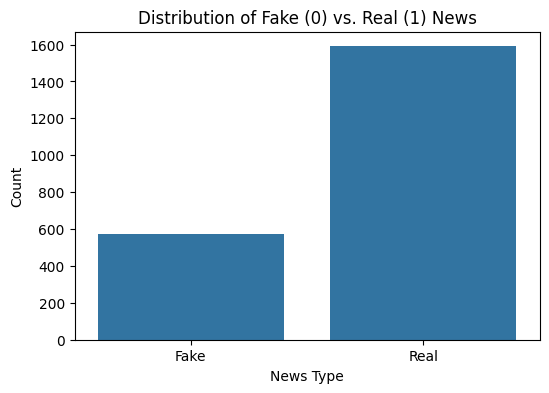

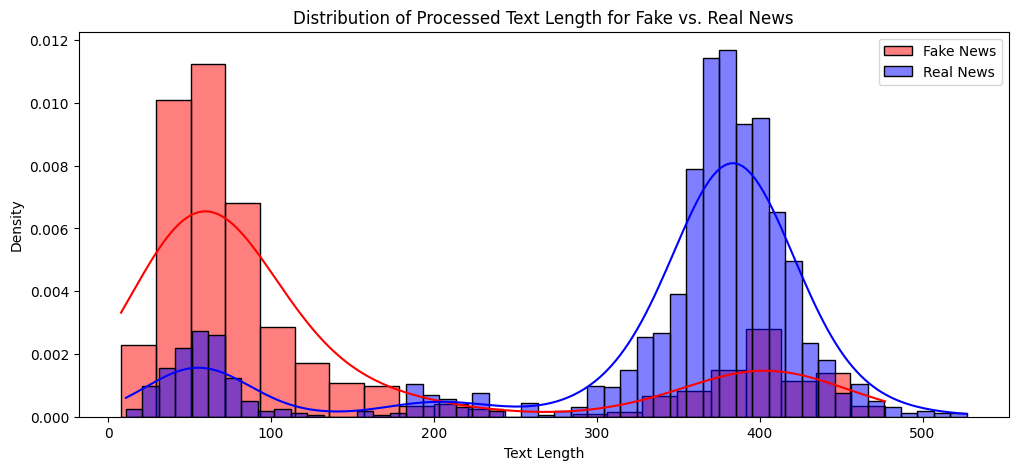

In [55]:
# Distribution of fake vs real news
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Fake (0) vs. Real (1) News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Fake', 'Real'])
plt.show()

# Text length distribution
df['text_length'] = df['processed_text'].apply(len)

plt.figure(figsize=(12, 5))
sns.histplot(df[df['label']==0]['text_length'], color='red', label='Fake News', kde=True, stat='density', alpha=0.5)
sns.histplot(df[df['label']==1]['text_length'], color='blue', label='Real News', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Processed Text Length for Fake vs. Real News')
plt.xlabel('Text Length')
plt.ylabel('Density')
plt.legend()
plt.show()

/tmp/ipykernel_438/2829695286.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[1] for word in common_words_fake], y=[word[0] for word in common_words_fake], palette='viridis')


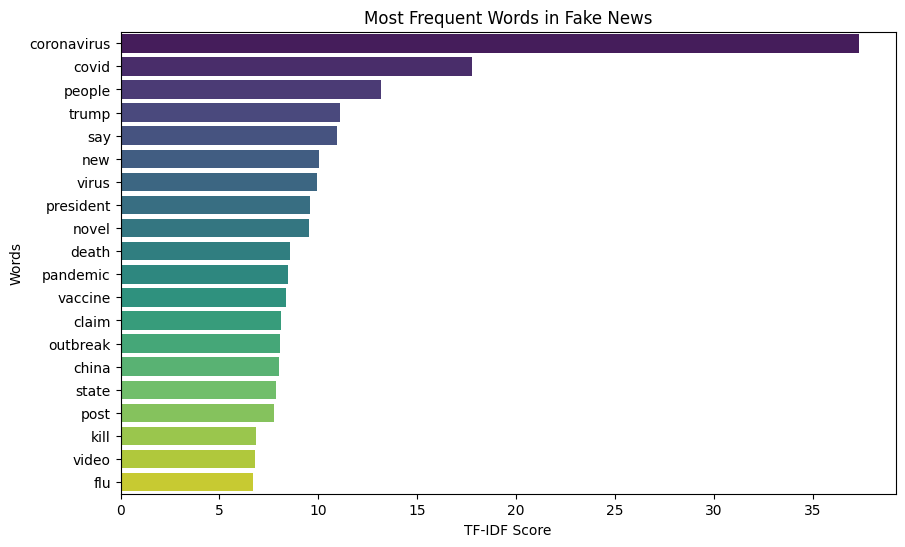

/tmp/ipykernel_438/2829695286.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[1] for word in common_words_real], y=[word[0] for word in common_words_real], palette='viridis')


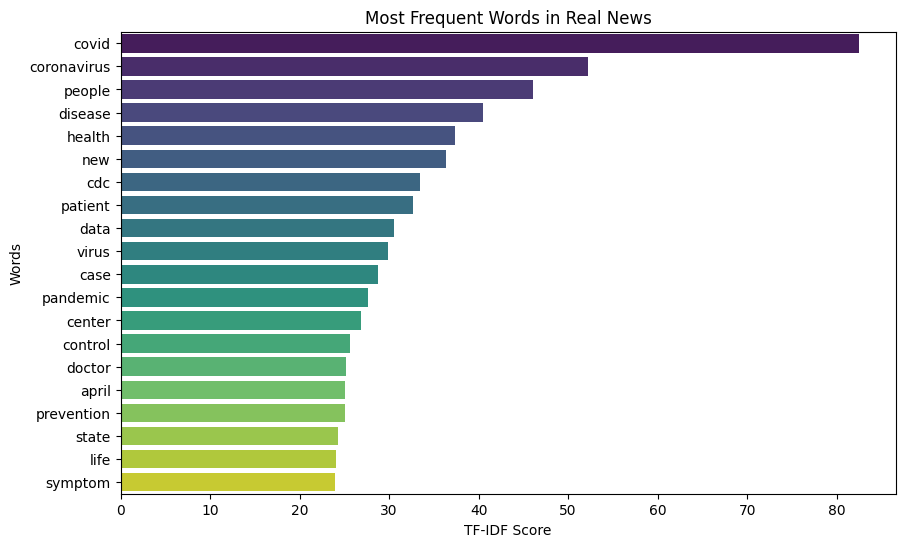

In [56]:
# Helper function to get most frequent words
def get_top_n_words(corpus, n=10):
    vec = TfidfVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Most frequent words in fake news
common_words_fake = get_top_n_words(df[df['label']==0]['processed_text'], 20)
plt.figure(figsize=(10, 6))
sns.barplot(x=[word[1] for word in common_words_fake], y=[word[0] for word in common_words_fake], palette='viridis')
plt.title('Most Frequent Words in Fake News')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.show()

# Most frequent words in real news
common_words_real = get_top_n_words(df[df['label']==1]['processed_text'], 20)
plt.figure(figsize=(10, 6))
sns.barplot(x=[word[1] for word in common_words_real], y=[word[0] for word in common_words_real], palette='viridis')
plt.title('Most Frequent Words in Real News')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.show()

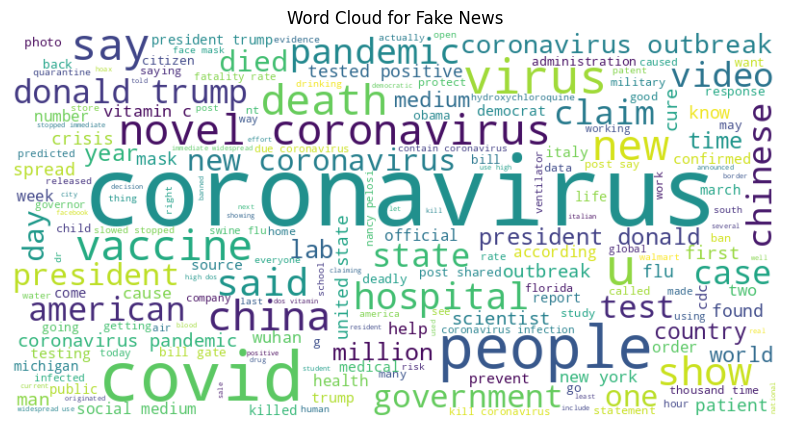

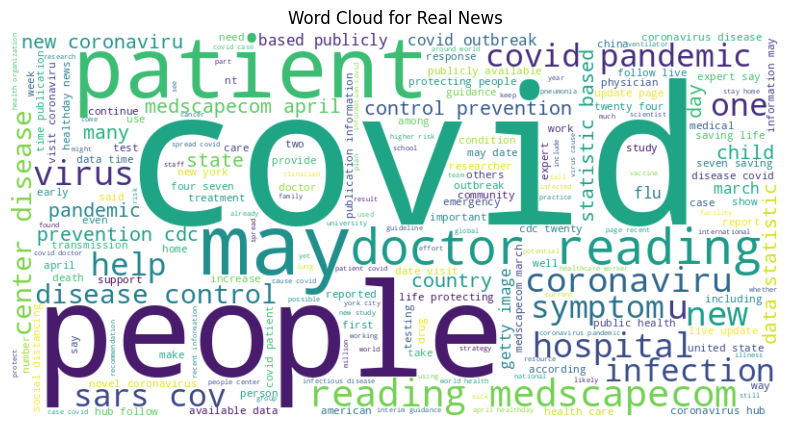

In [57]:
# Word Cloud for Fake News
fake_news_text = ' '.join(df[df['label']==0]['processed_text'].dropna())
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_news_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Fake News')
plt.show()

# Word Cloud for Real News
real_news_text = ' '.join(df[df['label']==1]['processed_text'].dropna())
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_news_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Real News')
plt.show()

## 5. Apply K-Means Clustering

### Determine Optimal Number of Clusters using Elbow Method

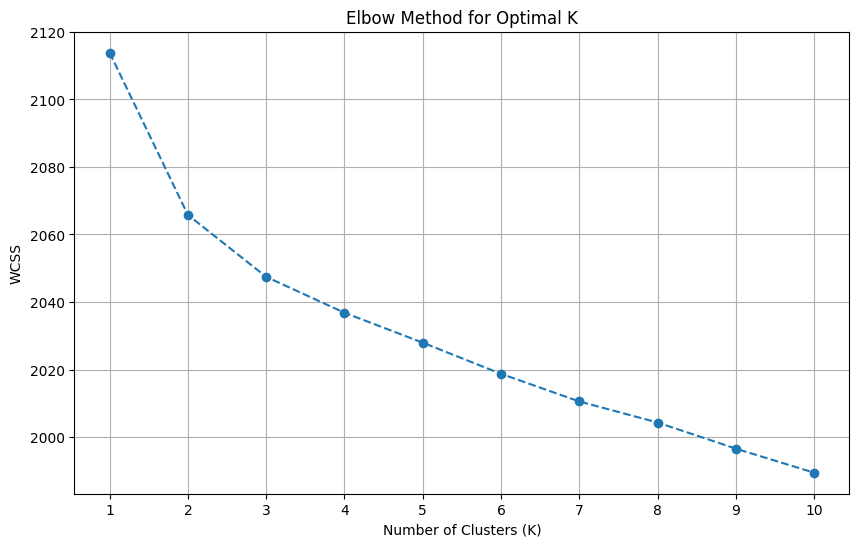

Based on the Elbow Method plot, choose an optimal 'K' where the rate of decrease in WCSS significantly changes. For demonstration purposes, let's choose K=4.


In [58]:
# Elbow Method to determine optimal number of clusters
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Based on the Elbow Method plot, choose an optimal 'K' where the rate of decrease in WCSS significantly changes. For demonstration purposes, let's choose K=4.")

### Apply K-Means Clustering and Add Labels to Dataset

In [59]:
# Apply K-Means clustering with the chosen optimal K (e.g., K=4 based on a hypothetical elbow)
k = 4 # You might adjust this based on the Elbow Method plot
kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_tfidf)
df['cluster_label'] = cluster_labels

print("First 5 rows with new 'cluster_label' column:")
display(df.head())

First 5 rows with new 'cluster_label' column:


,Unnamed: 0,type,fact_check_url,archive,news_url,news_url2,news_url3,news_url4,news_url5,title,newstitle,content,abstract,publish_date,meta_keywords,label,full_text,processed_text,text_length,cluster_label
0,0,post,https://factcheck.afp.com/false-advice-refusin...,https://perma.cc/J4N6-39D5,https://www.facebook.com/photo.php?fbid=551960...,NaN,NaN,NaN,NaN,Facebook posts shared in at least three countr...,NaN,NaN,NaN,NaN,NaN,0,Facebook posts shared in at least three countr...,facebook post shared least three country scien...,118,0
1,1,article,https://www.politifact.com/factchecks/2020/apr...,NaN,http://legis.wisconsin.gov/assembly/republican...,NaN,NaN,NaN,NaN,Wisconsin is Òclearly seeing a decline in COVI...,"""Wisconsin Legislature Takes Gov. Evers to Court""",speaker robin vos r rochester and senate major...,NaN,NaN,"""""",0,Wisconsin is Òclearly seeing a decline in COVI...,wisconsin clearly seeing decline covid infecti...,438,0
2,2,post,https://factcheck.afp.com/posts-claim-children...,https://perma.cc/V4HX-M2XJ,https://www.facebook.com/iAmJessenia/photos/a....,NaN,NaN,NaN,NaN,Facebook posts claim a child who is infected w...,NaN,NaN,NaN,NaN,NaN,0,Facebook posts claim a child who is infected w...,facebook post claim child infected novel coron...,81,0
3,3,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/kokernagnews/photos/a...,NaN,NaN,NaN,NaN,IndiaÕs Ministry of Home Affairs banning citiz...,NaN,NaN,NaN,NaN,NaN,0,IndiaÕs Ministry of Home Affairs banning citiz...,india ministry home affair banning citizen pos...,80,0
4,5,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/photo.php?fbid=102193...,NaN,NaN,NaN,NaN,"42 Democratic senators, plus two Independents,...",NaN,NaN,NaN,NaN,NaN,0,"42 Democratic senators, plus two Independents,...",democratic senator plus two independent voted ...,120,0


### Visualize Clusters with PCA

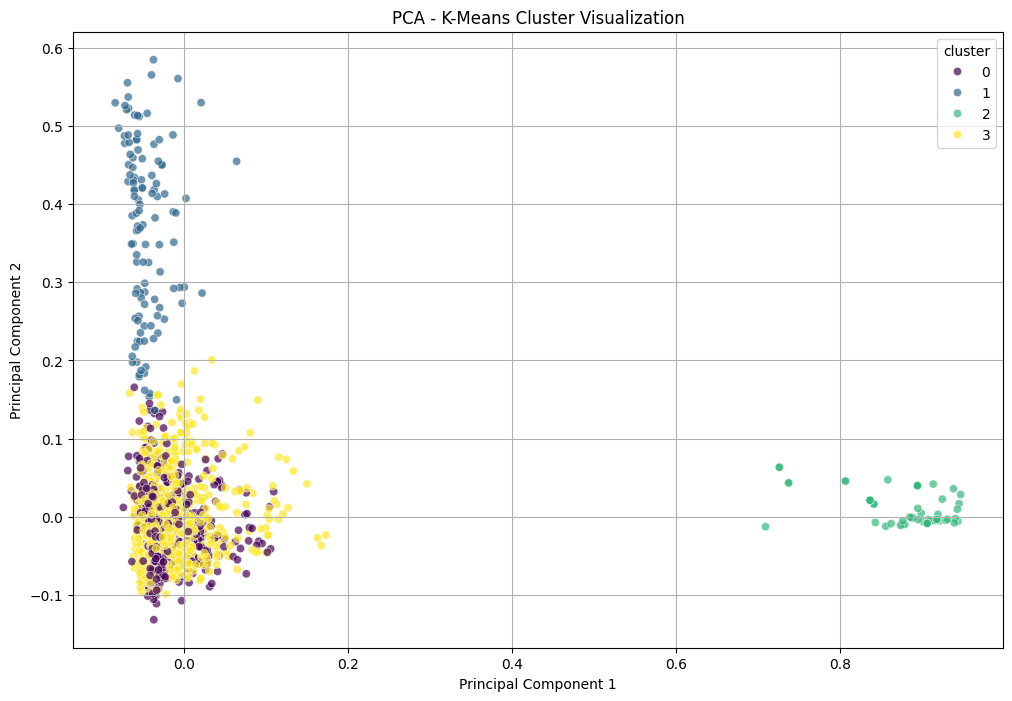

/tmp/ipykernel_438/4193525042.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_label', data=df, palette='viridis')


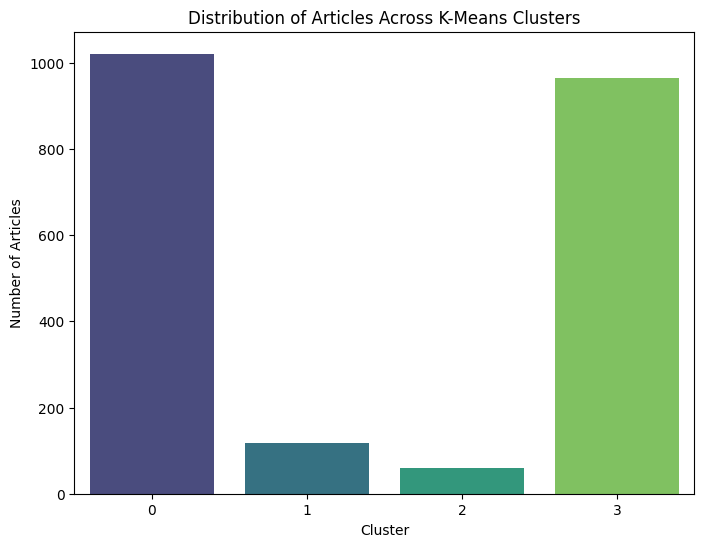

In [60]:
# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_tfidf.toarray()) # Convert sparse matrix to dense array for PCA
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
pca_df['true_label'] = df['label']

# PCA Cluster Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='viridis', data=pca_df, legend='full', alpha=0.7)
plt.title('PCA - K-Means Cluster Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Cluster Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster_label', data=df, palette='viridis')
plt.title('Distribution of Articles Across K-Means Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Articles')
plt.show()

## 6. Train a Supervised Model

In [61]:
# Combine TF-IDF features with cluster labels
# Ensure X_tfidf is a dense array or DataFrame for concatenation
if hasattr(X_tfidf, 'toarray'):
    X_combined = np.hstack((X_tfidf.toarray(), df[['cluster_label']].values))
else:
    X_combined = np.hstack((X_tfidf, df[['cluster_label']].values))

y = df['label'] # Target variable (fake vs real news)

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1729, 5001)
Shape of X_test: (433, 5001)
Shape of y_train: (1729,)
Shape of y_test: (433,)


In [62]:
# Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


## 7. Model Evaluation

In [63]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy Score: 0.9446

Confusion Matrix:
[[100  15]
 [  9 309]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       115
           1       0.95      0.97      0.96       318

    accuracy                           0.94       433
   macro avg       0.94      0.92      0.93       433
weighted avg       0.94      0.94      0.94       433



## 8. Model Interpretation and Visualization

/tmp/ipykernel_438/140474761.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:20]], y=[feature_names[i] for i in indices[:20]], palette='viridis')


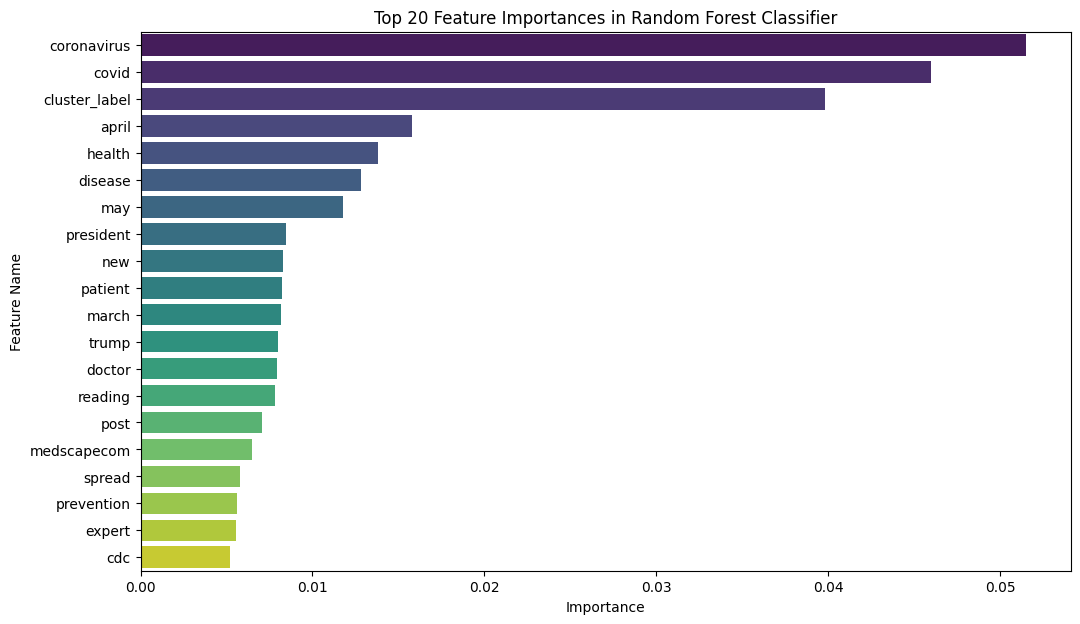

In [64]:
# Feature Importance Plot
if hasattr(rf_classifier, 'feature_importances_'):
    # Get feature names from TF-IDF vectorizer and add 'cluster_label'
    feature_names = tfidf_vectorizer.get_feature_names_out().tolist()
    feature_names.append('cluster_label') # Add cluster label as a feature

    importances = rf_classifier.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 7))
    sns.barplot(x=importances[indices[:20]], y=[feature_names[i] for i in indices[:20]], palette='viridis')
    plt.title('Top 20 Feature Importances in Random Forest Classifier')
    plt.xlabel('Importance')
    plt.ylabel('Feature Name')
    plt.show()
else:
    print("Random Forest Classifier does not have feature_importances_ attribute.")

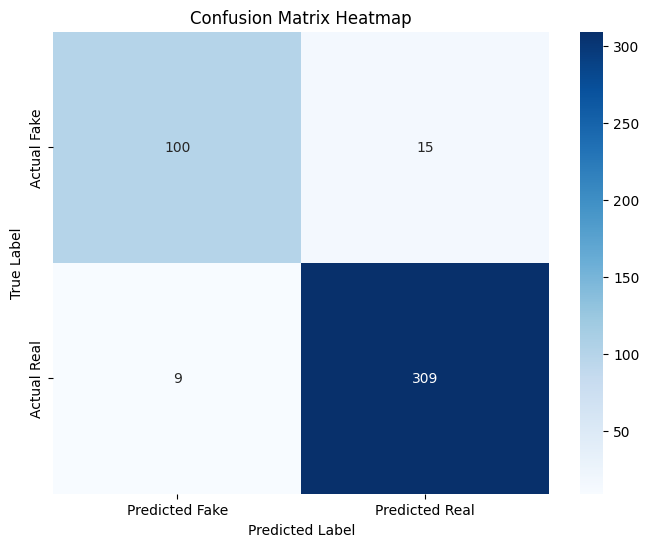

In [65]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Fake', 'Predicted Real'], yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

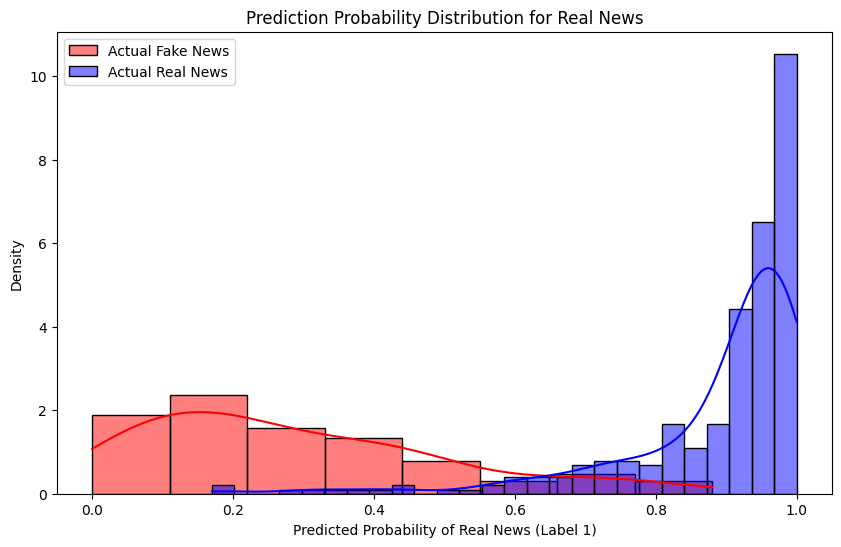

In [66]:
# Prediction Probability Distribution
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1] # Probability of being real news

plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba[y_test == 0], color='red', label='Actual Fake News', kde=True, stat='density', alpha=0.5)
sns.histplot(y_pred_proba[y_test == 1], color='blue', label='Actual Real News', kde=True, stat='density', alpha=0.5)
plt.title('Prediction Probability Distribution for Real News')
plt.xlabel('Predicted Probability of Real News (Label 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

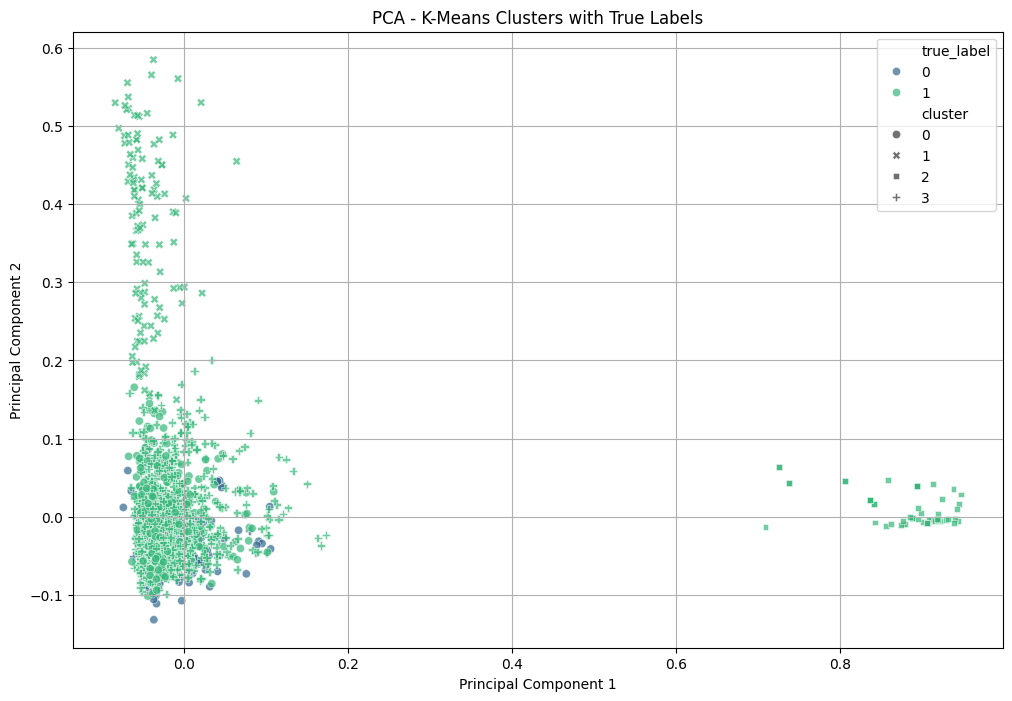

In [67]:
# Cluster Visualization with True Labels (Re-using PCA for consistency)
# (PCA plot already generated in step 6, this is to show clusters overlaid with true labels)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='true_label', style='cluster', palette='viridis', data=pca_df, legend='full', alpha=0.7)
plt.title('PCA - K-Means Clusters with True Labels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## 9. Final Output Explanation

This comprehensive pipeline demonstrates how unsupervised learning (K-Means) can be integrated with supervised learning (Random Forest) to improve the classification of misinformation in news articles. Here's a breakdown of how each step contributes:

### How K-Means Clustering Helps Identify Hidden Patterns:

K-Means clustering is an unsupervised machine learning algorithm that groups similar data points into clusters. In this pipeline:

*   **Pattern Detection**: By applying K-Means to the TF-IDF features of the processed text, we can identify natural groupings or `clusters` within the news articles based on their textual content. These clusters might represent different topics, writing styles, or thematic characteristics that are not explicitly labeled.
*   **Feature Enrichment**: The `cluster_label` generated by K-Means acts as a new, high-level categorical feature. It provides the supervised model (Random Forest) with additional contextual information derived from the inherent structure of the text data. Instead of just individual word importance, the model also gets a signal about which 'group' of articles a given news piece belongs to.
*   **Improved Generalization**: By incorporating these patterns, the supervised model can potentially generalize better, especially if certain types of misinformation or real news tend to fall into specific clusters. This allows the model to leverage both explicit labels and implicit textual relationships.

### How Random Forest Performs Classification:

Random Forest is a powerful ensemble supervised learning algorithm composed of multiple decision trees. In this pipeline:

*   **Robustness**: It builds numerous decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. This ensemble approach makes it robust to overfitting and generally improves accuracy.
*   **Feature Combination**: The Random Forest classifier takes the combined features (TF-IDF vectors + `cluster_label`) as input. It learns complex relationships between these features and the `label` (fake or real news).
*   **Decision Making**: Each decision tree in the forest makes a prediction, and the final prediction is determined by a majority vote. This allows the model to effectively capture non-linear interactions between textual features and the cluster information to classify news articles.

### How the Hybrid ML Approach Improves Misinformation Detection:

Combining K-Means Clustering with Random Forest offers several advantages for misinformation detection:

1.  **Enhanced Feature Representation**: The `cluster_label` adds a new dimension to the dataset that captures latent semantic structures. This richer feature set can help the Random Forest model to distinguish subtle differences between fake and real news that might not be apparent from TF-IDF features alone.
2.  **Contextual Understanding**: K-Means provides a 'context' for each article by grouping it with similar articles. For example, a cluster might predominantly contain articles discussing conspiracy theories, regardless of whether they are fake or real news. Knowing an article belongs to such a cluster can provide valuable context to the Random Forest model when making a classification decision.
3.  **Improved Performance**: By leveraging the strengths of both unsupervised (pattern discovery) and supervised (classification accuracy) learning, the hybrid model can potentially achieve higher accuracy, precision, recall, and F1-score compared to using either approach in isolation. The clustering can help organize the data in a way that makes the supervised task easier.
4.  **Interpretability (through clusters)**: While Random Forest itself can be complex, the clusters can offer some level of interpretability, by allowing us to analyze the common themes or characteristics of articles within each cluster and how those clusters relate to the true labels (fake vs. real news).